IMPORT LIBRARIES

In [1]:
# Install if needed:
# !pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error

CREATE SIMULATED TRAFFIC DATASET

In [2]:
np.random.seed(42)

data_size = 1000

data = pd.DataFrame({
    "vehicle_count": np.random.randint(10, 120, data_size),
    "signal_duration": np.random.randint(30, 180, data_size),
    "avg_wait_time": np.random.randint(20, 150, data_size),
    "temperature": np.random.randint(20, 45, data_size),
    "aqi": np.random.randint(50, 300, data_size)
})

# Idle probability logic (simulated)
data["idle_engine"] = (
    (data["vehicle_count"] > 60) & 
    (data["signal_duration"] > 90)
).astype(int)

# CO2 emission estimation (simulated formula)
data["co2_emission"] = (
    data["vehicle_count"] * data["signal_duration"] * 0.02
)

data.head()

,vehicle_count,signal_duration,avg_wait_time,temperature,aqi,idle_engine,co2_emission
0,112,125,103,42,231,1,280.00
1,61,122,147,25,197,1,148.84
2,102,90,145,23,157,0,183.60
3,24,151,64,37,196,0,72.48
4,116,80,71,28,133,0,185.60


TRAIN ML MODEL(CLASSIFICATION)

In [3]:
X = data[["vehicle_count", "signal_duration", "avg_wait_time", "temperature", "aqi"]]
y = data["idle_engine"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

classifier = RandomForestClassifier()
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       129
           1       1.00      1.00      1.00        71

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



TRAIN REGRESSION MODEL

In [4]:
X_reg = data[["vehicle_count", "signal_duration", "avg_wait_time", "aqi"]]
y_reg = data["co2_emission"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

regressor = LinearRegression()
regressor.fit(X_train_r, y_train_r)

y_pred_r = regressor.predict(X_test_r)

print("Mean Squared Error:", mean_squared_error(y_test_r, y_pred_r))

Mean Squared Error: 801.1821614516332


MAKE REAL-TIME PREDICTION

In [5]:
# Example real traffic input
new_data = pd.DataFrame({
    "vehicle_count": [85],
    "signal_duration": [120],
    "avg_wait_time": [100],
    "temperature": [35],
    "aqi": [220]
})

idle_prediction = classifier.predict(new_data)
co2_prediction = regressor.predict(new_data[["vehicle_count","signal_duration","avg_wait_time","aqi"]])

print("Idle Engine Probability:", "High" if idle_prediction[0]==1 else "Low")
print("Estimated CO2 Emission:", round(co2_prediction[0],2))

Idle Engine Probability: High
Estimated CO2 Emission: 196.94


VISUALISATION 

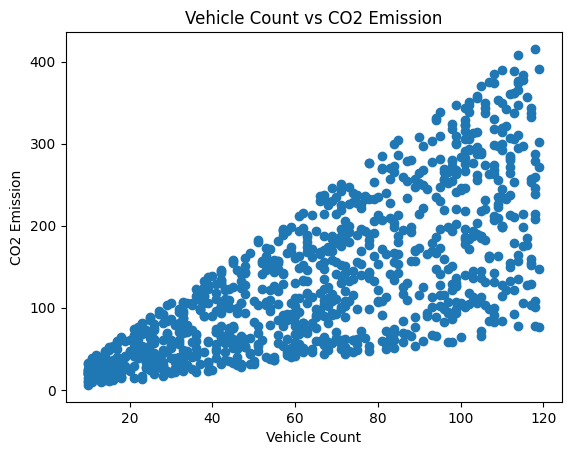

In [6]:
plt.figure()
plt.scatter(data["vehicle_count"], data["co2_emission"])
plt.xlabel("Vehicle Count")
plt.ylabel("CO2 Emission")
plt.title("Vehicle Count vs CO2 Emission")
plt.show()

SIMPLE DECISION ENGINE LOGIC

In [7]:
if idle_prediction[0] == 1:
    print("⚠️ High Idle Detected!")
    print("➡ Suggest reducing red signal duration.")
else:
    print("Traffic condition normal.")

⚠️ High Idle Detected!
➡ Suggest reducing red signal duration.


INSTALL REQUIRED LIBRARIES 

In [8]:
!pip install opencv-python

VEHICLE DETECTION FROM VIDEO
(use any traffic video file like traffic.mp4)

In [27]:
import cv2
import pandas as pd
import joblib

idle_model = joblib.load("idle_prediction_model.pkl")

video = cv2.VideoCapture(r"C:\Users\LIKITHA\Downloads\Traffic Flow In The Highway - 4K Stock Videos  NoCopyright  AllVideoFree.mp4")
vehicle_cascade = cv2.CascadeClassifier(r"C:\Users\LIKITHA\Downloads\cars.xml")

while True:
    ret, frame = video.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    vehicles = vehicle_cascade.detectMultiScale(gray, 1.1, 3)

    vehicle_count = len(vehicles)

    # Draw rectangles
    for (x, y, w, h) in vehicles:
        cv2.rectangle(frame, (x,y), (x+w,y+h), (255,0,0), 2)

    # ---------------- ML PART (MOVE HERE) ----------------
    input_data = pd.DataFrame({
        "vehicle_count":[vehicle_count],
        "signal_duration":[90],
        "avg_wait_time":[60],
        "temperature":[30],
        "aqi":[150],
    })

    idle_pred = idle_model.predict(input_data)

    if idle_pred[0] == 1:
        status = "HIGH IDLE"
        color = (0,0,255)
    else:
        status = "NORMAL"
        color = (0,255,0)

    # Display
    cv2.putText(frame, f"Vehicle Count: {vehicle_count}",
                (20,50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    cv2.putText(frame, f"Idle Status: {status}",
                (20,90), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

    cv2.imshow("Vehicle Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

video.release()
cv2.destroyAllWindows()

KeyboardInterrupt: 

IMPORT LIBRARIES

In [9]:
import numpy as np
import random

DEFINE ENVIRONMENT 

In [10]:
# Traffic density levels
states = ["Low", "Medium", "High"]

# Actions
actions = ["Reduce_Red", "Maintain", "Increase_Red"]

# Q-table
Q = np.zeros((len(states), len(actions)))

# Hyperparameters
learning_rate = 0.1
discount_factor = 0.9
epsilon = 0.2
episodes = 1000

REWARD FUNCTION 

In [11]:
def get_reward(state, action):
    if state == "High" and action == "Reduce_Red":
        return 10
    elif state == "High" and action == "Increase_Red":
        return -10
    elif state == "Low" and action == "Increase_Red":
        return 5
    else:
        return -2

TRAINING LOOP

In [12]:
for episode in range(episodes):
    state_index = random.randint(0, 2)

    if random.uniform(0,1) < epsilon:
        action_index = random.randint(0,2)
    else:
        action_index = np.argmax(Q[state_index])

    reward = get_reward(states[state_index], actions[action_index])

    Q[state_index, action_index] = Q[state_index, action_index] + \
        learning_rate * (reward + discount_factor * np.max(Q[state_index]) - Q[state_index, action_index])

print("Trained Q-Table:")
print(Q)

Trained Q-Table:
[[ 32.69150631  31.99271259  47.31582002]
 [-13.44550657 -13.45624477 -13.40519246]
 [ 94.35497779  59.49147203  46.69483221]]


OPTIMAL POLICY

In [13]:
for i, state in enumerate(states):
    best_action = actions[np.argmax(Q[i])]
    print(f"For {state} traffic → Best Action: {best_action}")

For Low traffic → Best Action: Increase_Red
For Medium traffic → Best Action: Increase_Red
For High traffic → Best Action: Reduce_Red


SAVE MODEL

In [14]:
import joblib

joblib.dump(classifier, "idle_prediction_model.pkl")
joblib.dump(regressor, "co2_prediction_model.pkl")

['co2_prediction_model.pkl']

LOAD MODEL

In [15]:
idle_model = joblib.load("idle_prediction_model.pkl")
co2_model = joblib.load("co2_prediction_model.pkl")

BASIC YOLO DETECTION VEHICLES CODE

In [9]:
from ultralytics import YOLO
import cv2

model = YOLO("yolov8n.pt")  # lightweight model

cap = cv2.VideoCapture(0)  # 0 for webcam

while True:
    ret, frame = cap.read()
    results = model(frame)

    vehicle_count = 0

    for r in results:
        for box in r.boxes:
            cls = int(box.cls[0])
            label = model.names[cls]

            if label in ["car", "truck", "bus", "motorcycle"]:
                vehicle_count += 1

    print("Vehicle Count:", vehicle_count)

    cv2.imshow("Traffic Detection", frame)

    if cv2.waitKey(1) == 27:
        break

cap.release()
cv2.destroyAllWindows()


0: 480x640 3 persons, 257.2ms
Speed: 10.4ms preprocess, 257.2ms inference, 24.2ms postprocess per image at shape (1, 3, 480, 640)
Vehicle Count: 0

0: 480x640 4 persons, 154.3ms
Speed: 5.0ms preprocess, 154.3ms inference, 5.5ms postprocess per image at shape (1, 3, 480, 640)
Vehicle Count: 0

0: 480x640 4 persons, 175.0ms
Speed: 2.6ms preprocess, 175.0ms inference, 8.3ms postprocess per image at shape (1, 3, 480, 640)
Vehicle Count: 0

0: 480x640 3 persons, 108.1ms
Speed: 3.7ms preprocess, 108.1ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)
Vehicle Count: 0

0: 480x640 4 persons, 98.4ms
Speed: 3.3ms preprocess, 98.4ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)
Vehicle Count: 0

0: 480x640 4 persons, 101.9ms
Speed: 3.0ms preprocess, 101.9ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)
Vehicle Count: 0

0: 480x640 4 persons, 101.4ms
Speed: 3.1ms preprocess, 101.4ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 

KeyboardInterrupt: 